In [6]:
!pip install tensorflow

In [14]:
pip install librosa


   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 2.2 MB/s eta 0:00:00


In [1]:
pip install resampy

   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.1 MB 4.2 MB/s eta 0:00:01
   ------------- -------------------------- 1.0/3.1 MB 2.3 MB/s eta 0:00:01
   ----------------------- ---------------- 1.8/3.1 MB 2.5 MB/s eta 0:00:01
   ------------------------------ --------- 2.4/3.1 MB 2.7 MB/s eta 0:00:01
   ------------------------------------- -- 2.9/3.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 3.1/3.1 MB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install librosa soundfile audioread

2026-06-09 20:35:58,318 - INFO - Loading dataset...
C:\Users\pruth\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\pruth\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\pruth\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
2026-06-09 20:43:13,466 - INFO - Dataset loaded: (2880, 40, 40)
C:\Users\pruth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.p

2026-06-09 20:43:13,841 - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.1241 - loss: 13.6960 - val_accuracy: 0.1354 - val_loss: 2.0777
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.1259 - loss: 2.0773 - val_accuracy: 0.1250 - val_loss: 2.0753
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1311 - loss: 2.0745 - val_accuracy: 0.1250 - val_loss: 2.0728
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1224 - loss: 2.0724 - val_accuracy: 0.1250 - val_loss: 2.0706
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.1354 - loss: 2.0706 - val_accuracy: 0.1250 - val_loss: 2.0687
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1302 - loss: 2.0691 - val_accuracy: 0.1250 - val_loss: 2.0672
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1354 - loss: 2.0677 - val_accuracy: 0.1250 - val_loss: 2.0658
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1328 - loss: 2.0667 - val_accuracy: 0.1250 - 

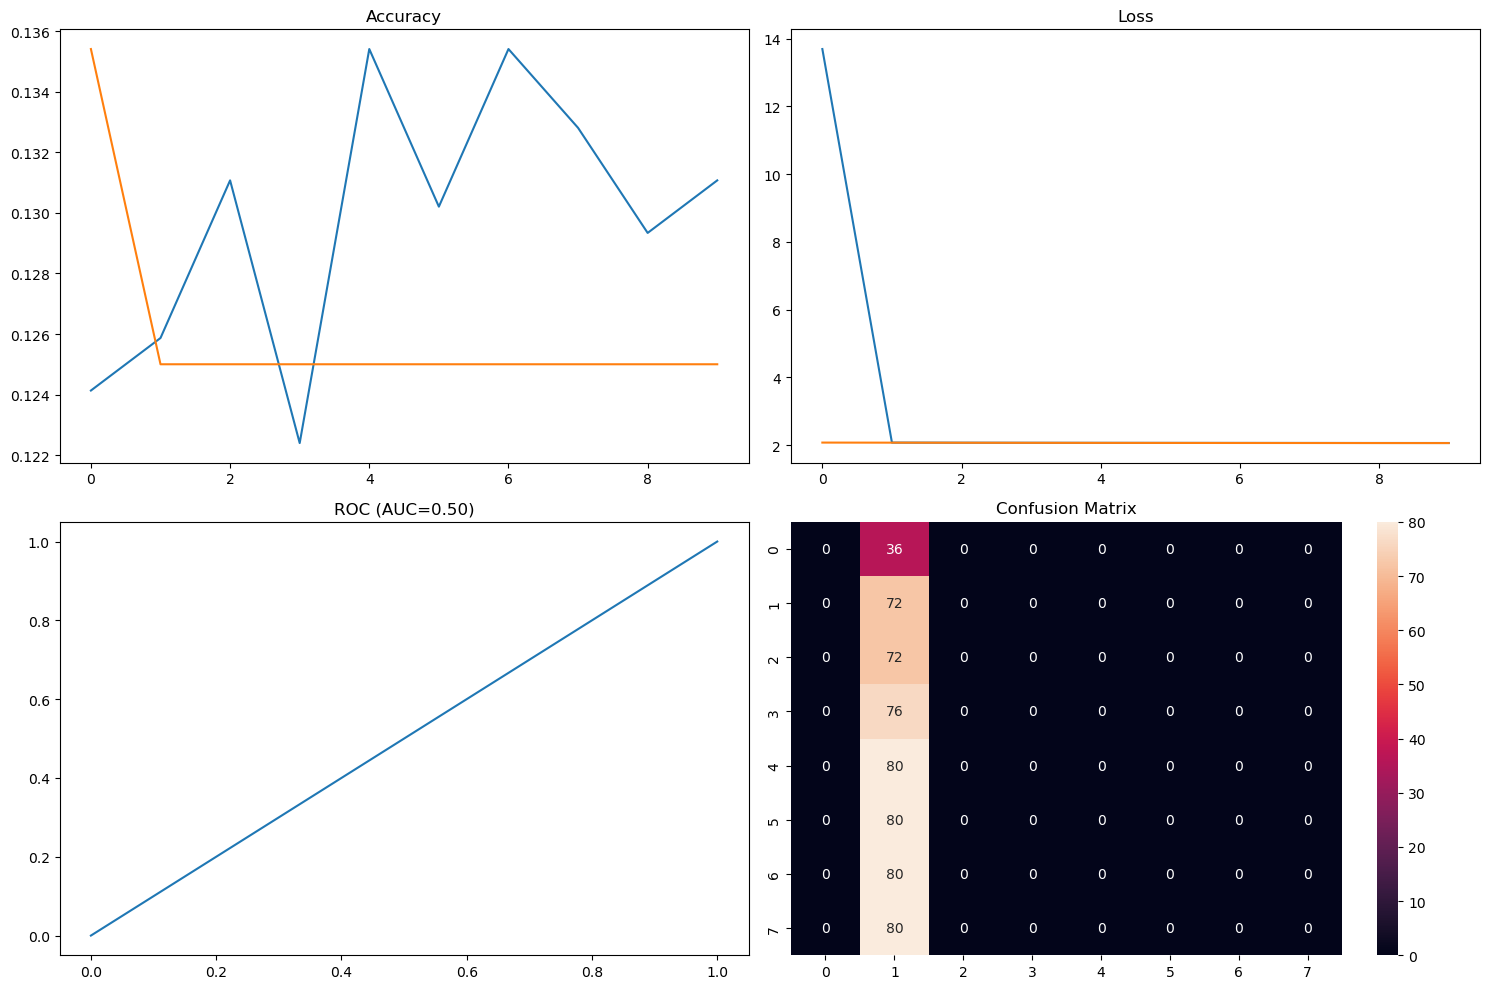

2026-06-09 20:44:05,966 - INFO - Report saved: emotion_report_20260609_204356.png
2026-06-09 20:44:06,034 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


In [2]:
import os
import logging
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import datetime

from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


# -------------------------
# 🎧 FEATURE EXTRACTION
# -------------------------
def extract_mfcc(file_path, max_pad_len=40):
    try:
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Padding
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc.T

    except Exception as e:
        logging.error(f"Error processing {file_path}: {e}")
        return None


# -------------------------
# 📂 LOAD DATASET
# -------------------------
def load_data(dataset_path):
    X, y = [], []

    emotion_map = {
        "01": 0,  # neutral
        "02": 1,  # calm
        "03": 2,  # happy
        "04": 3,  # sad
        "05": 4,  # angry
        "06": 5,  # fearful
        "07": 6,  # disgust
        "08": 7   # surprised
    }

    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)

                # Extract emotion from filename (RAVDESS format)
                emotion = file.split("-")[2]

                mfcc = extract_mfcc(file_path)

                if mfcc is not None:
                    X.append(mfcc)
                    y.append(emotion_map[emotion])

    return np.array(X), np.array(y)


# -------------------------
# 🤖 MODEL
# -------------------------
class SpeechEmotionCNN:
    def __init__(self, input_shape, num_classes):
        self.model = self._build_model(input_shape, num_classes)

    def _build_model(self, input_shape, num_classes):
        model = models.Sequential([
            layers.Conv1D(64, 3, activation='relu', input_shape=input_shape),
            layers.MaxPooling1D(2),

            layers.Conv1D(128, 3, activation='relu'),
            layers.MaxPooling1D(2),

            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),

            layers.Dense(num_classes, activation='softmax')
        ])

        model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

        return model


# -------------------------
# 🚀 MAIN
# -------------------------
def main():
    dataset_path = "dataset"   # 🔴 CHANGE THIS PATH

    logging.info("Loading dataset...")
    X, y = load_data(dataset_path)

    logging.info(f"Dataset loaded: {X.shape}")

    # Train-test split
    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    model_engine = SpeechEmotionCNN(input_shape=(40, 40), num_classes=8)

    early_stop = callbacks.EarlyStopping(patience=3, restore_best_weights=True)

    history = model_engine.model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        callbacks=[early_stop]
    )

    # -------------------------
    # 📊 EVALUATION
    # -------------------------
    y_pred_prob = model_engine.model.predict(X_val)
    y_pred = np.argmax(y_pred_prob, axis=1)

    cm = confusion_matrix(y_val, y_pred)

    # ROC (class 1 example)
    y_val_bin = label_binarize(y_val, classes=list(range(8)))
    fpr, tpr, _ = roc_curve(y_val_bin[:,1], y_pred_prob[:,1])
    roc_auc = auc(fpr, tpr)

    # -------------------------
    # 📈 PLOT
    # -------------------------
    plt.figure(figsize=(15, 10))

    # Accuracy
    plt.subplot(2,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Accuracy")

    # Loss
    plt.subplot(2,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Loss")

    # ROC
    plt.subplot(2,2,3)
    plt.plot(fpr, tpr)
    plt.title(f"ROC (AUC={roc_auc:.2f})")

    # Confusion Matrix
    plt.subplot(2,2,4)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")

    plt.tight_layout()

    # Save + Show
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    file_name = f"emotion_report_{timestamp}.png"

    plt.savefig(file_name, dpi=300)
    plt.show()

    logging.info(f"Report saved: {file_name}")

    # Save model
    model_engine.model.save("emotion_model.h5")


if __name__ == "__main__":
    main()

In [1]:
import os

count = 0
for root, dirs, files in os.walk("dataset"):
    for file in files:
        if file.endswith(".wav"):
            count += 1

print("Total audio files:", count)

Total audio files: 2880


In [ ]:
extract_mfcc(...)
load_data(...)
train_and_generate_report(...)